# Evaluation of KNN-Based LinkedIn Sample Selection

This notebook evaluates the quality of the KNN-based selection algorithm for LinkedIn observations within SOEP-defined strata.

**Key Metrics:**
- Standardized Mean Difference (SMD) for experience distribution
- Within-cell balance analysis
- Sample size comparisons
- Distribution visualizations

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import path configurations
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))
from bonn_thesis.config import (
    LINKEDIN_MATCHED_TO_SOEP_BLD,
    MERGED_EXP_ED_SAMPLING_BLD,
    SOEP_DATA_BLD,
)

## Configuration

Define cell columns and parameters for evaluation.

In [2]:
# Cell definition
CELL_COLS = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

# Number of cells to sample for detailed within-cell analysis
N_SAMPLE_CELLS = 10
RANDOM_STATE = 42

print(f"Configuration:")
print(f"  Cell columns: {CELL_COLS}")
print(f"  Sample cells for detailed analysis: {N_SAMPLE_CELLS}")

Configuration:
  Cell columns: ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']
  Sample cells for detailed analysis: 10


## Step 1: Load Data

Load SOEP data, LinkedIn data before selection, LinkedIn data after selection, and metadata.

In [3]:
# Load SOEP data
soep_file = SOEP_DATA_BLD / "soep_clean.parquet"
soep_df = pd.read_parquet(soep_file, engine="fastparquet")
soep_df = soep_df.dropna(subset=["pgexpft"])

print(f"SOEP data: {len(soep_df):,} observations")
print(f"SOEP columns: {list(soep_df.columns)[:10]}...")

# Load LinkedIn data before selection (all strata files concatenated)
linkedin_files = sorted(MERGED_EXP_ED_SAMPLING_BLD.glob("linkedin_merged_exp_ed_strata_*.parquet"))
linkedin_dfs = []
for file in linkedin_files:
    df = pd.read_parquet(file, engine="fastparquet")
    linkedin_dfs.append(df)

linkedin_before = pd.concat(linkedin_dfs, ignore_index=True)
linkedin_before = linkedin_before[linkedin_before['custom_id'].notna()].dropna(subset=["pgexpft"])

print(f"\nLinkedIn before selection: {len(linkedin_before):,} observations")

# Load LinkedIn data after KNN selection
linkedin_after_file = LINKEDIN_MATCHED_TO_SOEP_BLD / "linkedin_selected.parquet"
linkedin_after = pd.read_parquet(linkedin_after_file, engine="fastparquet")
linkedin_after = linkedin_after.dropna(subset=["pgexpft"])

print(f"LinkedIn after KNN selection: {len(linkedin_after):,} observations")

# Load metadata
metadata_file = LINKEDIN_MATCHED_TO_SOEP_BLD / "linkedin_knn_metadata.jsonl"
with metadata_file.open("r") as f:
    metadata = json.load(f)

print(f"\nMetadata loaded:")
print(f"  Cells processed: {metadata['cells_processed']}")
print(f"  Cells with all selected: {metadata['cells_all_selected']}")
print(f"  Cells with KNN applied: {metadata['cells_knn_applied']}")

SOEP data: 70,150 observations
SOEP columns: ['hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro', 'pglabnet']...

LinkedIn before selection: 1,275,125 observations
LinkedIn after KNN selection: 29,178 observations

Metadata loaded:
  Cells processed: 1721
  Cells with all selected: 719
  Cells with KNN applied: 1002


## Step 2: Global Distribution Analysis

Calculate Standardized Mean Difference (SMD) for overall experience distribution.

In [4]:
def calculate_smd(treated_values, control_values):
    """Calculate Standardized Mean Difference (SMD).
    
    Args:
        treated_values: Array-like of treatment group values.
        control_values: Array-like of control group values.
    
    Returns:
        float: SMD value.
    """
    mean_treated = np.mean(treated_values)
    mean_control = np.mean(control_values)
    var_treated = np.var(treated_values, ddof=1)
    var_control = np.var(control_values, ddof=1)
    pooled_std = np.sqrt((var_treated + var_control) / 2)
    smd = (mean_treated - mean_control) / pooled_std
    return smd

# Extract experience values
soep_exp = soep_df['pgexpft'].dropna()
linkedin_exp_before = linkedin_before['pgexpft'].dropna()
linkedin_exp_after = linkedin_after['pgexpft'].dropna()

# Calculate SMD
smd_before = calculate_smd(soep_exp, linkedin_exp_before)
smd_after = calculate_smd(soep_exp, linkedin_exp_after)

print("=== Global Experience Distribution ===\n")
print(f"{'Dataset':<30} {'N':>10} {'Mean':>10} {'Std':>10} {'Min':>10} {'Median':>10} {'Max':>10}")
print("-" * 90)
print(f"{'SOEP (target)':<30} {len(soep_exp):>10,} {soep_exp.mean():>10.2f} {soep_exp.std():>10.2f} {soep_exp.min():>10.2f} {soep_exp.median():>10.2f} {soep_exp.max():>10.2f}")
print(f"{'LinkedIn (before selection)':<30} {len(linkedin_exp_before):>10,} {linkedin_exp_before.mean():>10.2f} {linkedin_exp_before.std():>10.2f} {linkedin_exp_before.min():>10.2f} {linkedin_exp_before.median():>10.2f} {linkedin_exp_before.max():>10.2f}")
print(f"{'LinkedIn (after KNN)':<30} {len(linkedin_exp_after):>10,} {linkedin_exp_after.mean():>10.2f} {linkedin_exp_after.std():>10.2f} {linkedin_exp_after.min():>10.2f} {linkedin_exp_after.median():>10.2f} {linkedin_exp_after.max():>10.2f}")

print(f"\n=== Standardized Mean Difference (SMD) ===")
print(f"Before selection: {smd_before:>7.4f}")
print(f"After selection:  {smd_after:>7.4f}")
print(f"Improvement:      {abs(smd_before) - abs(smd_after):>7.4f}")

print(f"\nInterpretation:")
print(f"  |SMD| < 0.1:  Good balance ✓")
print(f"  |SMD| < 0.25: Acceptable balance")
print(f"  |SMD| >= 0.25: Imbalance")

if abs(smd_after) < 0.1:
    result = "✓ Good balance achieved"
elif abs(smd_after) < 0.25:
    result = "Acceptable balance achieved"
else:
    result = "⚠ Some imbalance remains"

print(f"\nResult: {result}")

=== Global Experience Distribution ===

Dataset                                 N       Mean        Std        Min     Median        Max
------------------------------------------------------------------------------------------
SOEP (target)                      70,150      18.72      11.74       0.00      18.25      61.00
LinkedIn (before selection)     1,275,125       9.10       7.18       0.08       7.25      68.16
LinkedIn (after KNN)               29,178      10.96       9.65       0.08       8.08      48.58

=== Standardized Mean Difference (SMD) ===
Before selection:  0.9894
After selection:   0.7224
Improvement:       0.2670

Interpretation:
  |SMD| < 0.1:  Good balance ✓
  |SMD| < 0.25: Acceptable balance
  |SMD| >= 0.25: Imbalance

Result: ⚠ Some imbalance remains


## Step 3: Visualize Distribution Changes

Compare experience distributions before and after KNN selection.

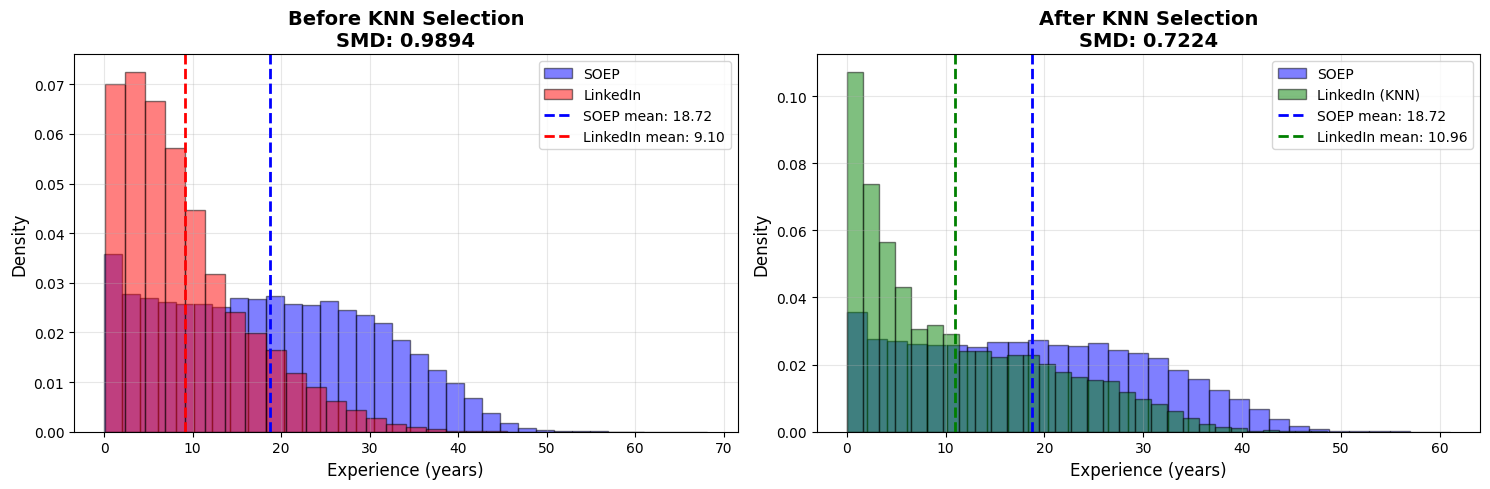

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before selection
axes[0].hist(soep_exp, bins=30, alpha=0.5, label='SOEP', density=True, color='blue', edgecolor='black')
axes[0].hist(linkedin_exp_before, bins=30, alpha=0.5, label='LinkedIn', density=True, color='red', edgecolor='black')
axes[0].axvline(soep_exp.mean(), color='blue', linestyle='--', linewidth=2, label=f'SOEP mean: {soep_exp.mean():.2f}')
axes[0].axvline(linkedin_exp_before.mean(), color='red', linestyle='--', linewidth=2, label=f'LinkedIn mean: {linkedin_exp_before.mean():.2f}')
axes[0].set_xlabel('Experience (years)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'Before KNN Selection\nSMD: {smd_before:.4f}', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# After selection
axes[1].hist(soep_exp, bins=30, alpha=0.5, label='SOEP', density=True, color='blue', edgecolor='black')
axes[1].hist(linkedin_exp_after, bins=30, alpha=0.5, label='LinkedIn (KNN)', density=True, color='green', edgecolor='black')
axes[1].axvline(soep_exp.mean(), color='blue', linestyle='--', linewidth=2, label=f'SOEP mean: {soep_exp.mean():.2f}')
axes[1].axvline(linkedin_exp_after.mean(), color='green', linestyle='--', linewidth=2, label=f'LinkedIn mean: {linkedin_exp_after.mean():.2f}')
axes[1].set_xlabel('Experience (years)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'After KNN Selection\nSMD: {smd_after:.4f}', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4: Within-Cell Balance Analysis

Evaluate balance within a sample of individual cells.

In [6]:
# Get unique cells from selected LinkedIn data
unique_cells = linkedin_after[CELL_COLS].drop_duplicates()

# Sample cells for detailed analysis
np.random.seed(RANDOM_STATE)
sample_cells = unique_cells.sample(n=min(N_SAMPLE_CELLS, len(unique_cells)), random_state=RANDOM_STATE)

print(f"=== Within-Cell Balance Analysis (Sample of {len(sample_cells)} Cells) ===\n")
print(f"{'Cell':<60} {'SOEP':>12} {'LI Before':>12} {'LI After':>12} {'SMD Before':>12} {'SMD After':>12}")
print("-" * 120)

within_cell_results = []

for idx, cell_row in sample_cells.iterrows():
    # Create masks for each dataset
    cell_mask_soep = True
    cell_mask_linkedin_before = True
    cell_mask_linkedin_after = True
    
    for col in CELL_COLS:
        cell_mask_soep &= (soep_df[col] == cell_row[col])
        cell_mask_linkedin_before &= (linkedin_before[col] == cell_row[col])
        cell_mask_linkedin_after &= (linkedin_after[col] == cell_row[col])
    
    # Extract cell data
    soep_cell_exp = soep_df[cell_mask_soep]['pgexpft'].dropna()
    linkedin_cell_exp_before = linkedin_before[cell_mask_linkedin_before]['pgexpft'].dropna()
    linkedin_cell_exp_after = linkedin_after[cell_mask_linkedin_after]['pgexpft'].dropna()
    
    if len(soep_cell_exp) > 1 and len(linkedin_cell_exp_after) > 1:
        cell_smd_before = calculate_smd(soep_cell_exp, linkedin_cell_exp_before) if len(linkedin_cell_exp_before) > 1 else np.nan
        cell_smd_after = calculate_smd(soep_cell_exp, linkedin_cell_exp_after)
        
        # Create short cell identifier
        cell_id = f"{cell_row['syear']} | {cell_row['isco_3_name'][:25]:25} | {cell_row['education_grouped'][:15]:15}"
        
        print(f"{cell_id:<60} {len(soep_cell_exp):>12} {len(linkedin_cell_exp_before):>12} {len(linkedin_cell_exp_after):>12} {cell_smd_before:>12.3f} {cell_smd_after:>12.3f}")
        
        within_cell_results.append({
            'cell': cell_id,
            'soep_n': len(soep_cell_exp),
            'linkedin_before_n': len(linkedin_cell_exp_before),
            'linkedin_after_n': len(linkedin_cell_exp_after),
            'smd_before': cell_smd_before,
            'smd_after': cell_smd_after,
        })

# Summary statistics
within_cell_df = pd.DataFrame(within_cell_results)
print(f"\n=== Within-Cell SMD Summary ===")
print(f"Before selection:")
print(f"  Mean |SMD|: {within_cell_df['smd_before'].abs().mean():.4f}")
print(f"  Median |SMD|: {within_cell_df['smd_before'].abs().median():.4f}")
print(f"  Cells with |SMD| < 0.1: {(within_cell_df['smd_before'].abs() < 0.1).sum()} / {len(within_cell_df)}")

print(f"\nAfter selection:")
print(f"  Mean |SMD|: {within_cell_df['smd_after'].abs().mean():.4f}")
print(f"  Median |SMD|: {within_cell_df['smd_after'].abs().median():.4f}")
print(f"  Cells with |SMD| < 0.1: {(within_cell_df['smd_after'].abs() < 0.1).sum()} / {len(within_cell_df)}")

=== Within-Cell Balance Analysis (Sample of 10 Cells) ===

Cell                                                                 SOEP    LI Before     LI After   SMD Before    SMD After
------------------------------------------------------------------------------------------------------------------------
2016.0 | Legal Professionals       | Master or Docto                    7          147           21        0.519        0.008
2016.0 | Assemblers                | Secondary educa                    6            8            8        1.894        1.894
2015.0 | Material Recording and Tr | Secondary educa                    6           12           12        0.857        0.857
2019.0 | Managing Directors and Ch | Secondary educa                    7           33           11        1.441        0.509
2013.0 | Engineering Professionals | Post-secondary                     6           96           16        0.740       -0.044
2014.0 | Electrotechnology Enginee | Bachelor degree            

## Step 5: Sample Size Analysis

Analyze how sample sizes changed across cells.

In [7]:
# Count observations per cell for all datasets
soep_cell_counts = soep_df.groupby(CELL_COLS).size().reset_index(name='soep_n')
linkedin_before_counts = linkedin_before.groupby(CELL_COLS).size().reset_index(name='linkedin_before_n')
linkedin_after_counts = linkedin_after.groupby(CELL_COLS).size().reset_index(name='linkedin_after_n')

# Merge counts
cell_counts = soep_cell_counts.merge(
    linkedin_before_counts, on=CELL_COLS, how='outer'
).merge(
    linkedin_after_counts, on=CELL_COLS, how='outer'
).fillna(0)

# Calculate ratio
cell_counts['ratio_before'] = cell_counts['linkedin_before_n'] / cell_counts['soep_n']
cell_counts['ratio_after'] = cell_counts['linkedin_after_n'] / cell_counts['soep_n']
cell_counts['reduction'] = cell_counts['linkedin_before_n'] - cell_counts['linkedin_after_n']
cell_counts['reduction_pct'] = (cell_counts['reduction'] / cell_counts['linkedin_before_n']) * 100

print("=== Sample Size Analysis ===\n")
print(f"Total cells: {len(cell_counts)}")
print(f"\nLinkedIn to SOEP ratio:")
print(f"  Before selection: {cell_counts['linkedin_before_n'].sum() / cell_counts['soep_n'].sum():.2f}")
print(f"  After selection:  {cell_counts['linkedin_after_n'].sum() / cell_counts['soep_n'].sum():.2f}")
print(f"  Target ratio:     {metadata['config']['matches_per_soep']}")

print(f"\nLinkedIn observations:")
print(f"  Before: {cell_counts['linkedin_before_n'].sum():,.0f}")
print(f"  After:  {cell_counts['linkedin_after_n'].sum():,.0f}")
print(f"  Reduction: {cell_counts['reduction'].sum():,.0f} ({cell_counts['reduction'].sum() / cell_counts['linkedin_before_n'].sum() * 100:.1f}%)")

print(f"\nCells by reduction category:")
print(f"  No reduction (all kept):     {(cell_counts['reduction'] == 0).sum()}")
print(f"  <25% reduction:              {((cell_counts['reduction_pct'] > 0) & (cell_counts['reduction_pct'] < 25)).sum()}")
print(f"  25-50% reduction:            {((cell_counts['reduction_pct'] >= 25) & (cell_counts['reduction_pct'] < 50)).sum()}")
print(f"  ≥50% reduction:              {(cell_counts['reduction_pct'] >= 50).sum()}")

=== Sample Size Analysis ===

Total cells: 27059

LinkedIn to SOEP ratio:
  Before selection: 18.18
  After selection:  0.42
  Target ratio:     3

LinkedIn observations:
  Before: 1,275,125
  After:  29,178
  Reduction: 1,245,947 (97.7%)

Cells by reduction category:
  No reduction (all kept):     9773
  <25% reduction:              0
  25-50% reduction:            26
  ≥50% reduction:              17260


## Step 6: Visualize Sample Size Changes

Scatter plot showing LinkedIn sample sizes before vs after selection.

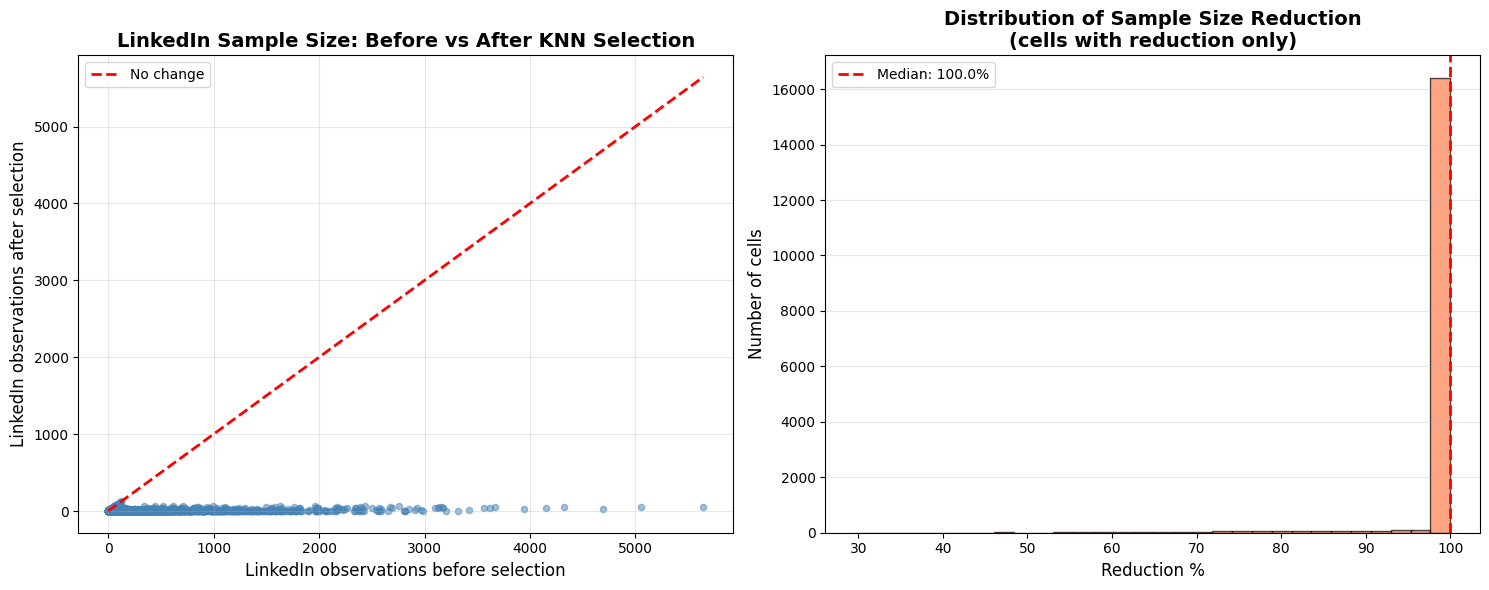

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: Before vs After
axes[0].scatter(cell_counts['linkedin_before_n'], cell_counts['linkedin_after_n'], 
                alpha=0.5, s=20, color='steelblue')
max_val = max(cell_counts['linkedin_before_n'].max(), cell_counts['linkedin_after_n'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='No change')
axes[0].set_xlabel('LinkedIn observations before selection', fontsize=12)
axes[0].set_ylabel('LinkedIn observations after selection', fontsize=12)
axes[0].set_title('LinkedIn Sample Size: Before vs After KNN Selection', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram: Reduction percentage
axes[1].hist(cell_counts[cell_counts['reduction'] > 0]['reduction_pct'], 
             bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(cell_counts[cell_counts['reduction'] > 0]['reduction_pct'].median(), 
                color='red', linestyle='--', linewidth=2, 
                label=f'Median: {cell_counts[cell_counts["reduction"] > 0]["reduction_pct"].median():.1f}%')
axes[1].set_xlabel('Reduction %', fontsize=12)
axes[1].set_ylabel('Number of cells', fontsize=12)
axes[1].set_title('Distribution of Sample Size Reduction\n(cells with reduction only)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 7: Summary and Recommendations

Overall assessment of KNN selection quality.

In [9]:
print("=" * 80)
print("KNN SELECTION EVALUATION SUMMARY")
print("=" * 80)

print(f"\n1. GLOBAL BALANCE")
print(f"   • SMD before: {smd_before:.4f}")
print(f"   • SMD after:  {smd_after:.4f}")
print(f"   • Improvement: {abs(smd_before) - abs(smd_after):.4f}")
if abs(smd_after) < 0.1:
    print(f"   ✓ Good balance achieved (|SMD| < 0.1)")
elif abs(smd_after) < 0.25:
    print(f"   ✓ Acceptable balance achieved (|SMD| < 0.25)")
else:
    print(f"   ⚠ Some imbalance remains (|SMD| >= 0.25)")

print(f"\n2. SAMPLE SIZE")
print(f"   • LinkedIn observations before: {len(linkedin_before):,}")
print(f"   • LinkedIn observations after:  {len(linkedin_after):,}")
print(f"   • Reduction: {len(linkedin_before) - len(linkedin_after):,} ({(1 - len(linkedin_after)/len(linkedin_before))*100:.1f}%)")
print(f"   • Actual ratio (LinkedIn/SOEP): {len(linkedin_after) / len(soep_df):.2f}")
print(f"   • Target ratio: {metadata['config']['matches_per_soep']}")

print(f"\n3. CELL-LEVEL ANALYSIS")
print(f"   • Total cells processed: {metadata['cells_processed']}")
print(f"   • Cells with all LinkedIn kept: {metadata['cells_all_selected']}")
print(f"   • Cells with KNN applied: {metadata['cells_knn_applied']}")
print(f"   • Cells with issues: {metadata['cells_with_issues']}")

if len(within_cell_results) > 0:
    print(f"\n4. WITHIN-CELL BALANCE (sample of {len(within_cell_results)} cells)")
    print(f"   • Mean |SMD| after selection: {within_cell_df['smd_after'].abs().mean():.4f}")
    print(f"   • Cells with good balance (|SMD| < 0.1): {(within_cell_df['smd_after'].abs() < 0.1).sum()} / {len(within_cell_df)}")

print(f"\n5. RECOMMENDATIONS")
if abs(smd_after) < 0.1 and (within_cell_df['smd_after'].abs() < 0.25).mean() > 0.8:
    print(f"   ✓ KNN selection achieved good balance. Ready for downstream analysis.")
elif abs(smd_after) < 0.25:
    print(f"   ✓ KNN selection achieved acceptable balance. Consider sensitivity analysis.")
else:
    print(f"   ⚠ Consider adjusting MATCHES_PER_SOEP parameter or filtering strategy.")

print("\n" + "=" * 80)

KNN SELECTION EVALUATION SUMMARY

1. GLOBAL BALANCE
   • SMD before: 0.9894
   • SMD after:  0.7224
   • Improvement: 0.2670
   ⚠ Some imbalance remains (|SMD| >= 0.25)

2. SAMPLE SIZE
   • LinkedIn observations before: 1,275,125
   • LinkedIn observations after:  29,178
   • Reduction: 1,245,947 (97.7%)
   • Actual ratio (LinkedIn/SOEP): 0.42
   • Target ratio: 3

3. CELL-LEVEL ANALYSIS
   • Total cells processed: 1721
   • Cells with all LinkedIn kept: 719
   • Cells with KNN applied: 1002
   • Cells with issues: 0

4. WITHIN-CELL BALANCE (sample of 10 cells)
   • Mean |SMD| after selection: 0.7016
   • Cells with good balance (|SMD| < 0.1): 3 / 10

5. RECOMMENDATIONS
   ⚠ Consider adjusting MATCHES_PER_SOEP parameter or filtering strategy.

